# ISM-CyberRAG - Sprint 3 Development

**Final sprint** of the ISM CyberRAG pipeline for the Australian Information Security Manual.

Pipeline: Pre-Filter > Embed > Multi-Query Expand > Hybrid Search > Rerank > Rerank Threshold Check > Generate Answer > Evaluate (RAGAS) > Log (ClearML)

Sprint 3 adds multi-query expansion, a two-stage out-of-scope guardrail, a pipeline explorer UI, CI/CD, and deployment.

---

**Team Name:** Studio Builders

**Team Members:**

- Sreekar Reddy Edulapalli (25617806)
- Chandan Sreenivasaiah (25674250)
- Ruben Easo Thomas (25598184)

## 0 - Sprint 3 Objectives

This sprint focuses on three pipeline improvements and production readiness:

1. **Multi-Query Expansion**: For each user question, the LLM generates 3 alternate phrasings. All variants are searched independently and results are merged before reranking, improving recall on ambiguous or narrow queries.

2. **Two-Stage OOS Guardrail**: Stage 1 is a keyword pre-filter that catches obviously off-topic queries before embedding. Stage 2 checks the maximum rerank score against a calibrated threshold after retrieval. Together they prevent the LLM from hallucinating answers to questions outside the ISM.

3. **Deployment and CI/CD**: Package the pipeline as a deployable application with automated testing and continuous integration.

## 1 - Environment Setup

In [1]:
import os
import sys

cwd = os.getcwd()
if os.path.basename(cwd) == "notebooks":
    project_root = os.path.abspath(os.path.join(cwd, ".."))
else:
    project_root = cwd

if not os.path.exists(os.path.join(project_root, "src", "config.py")):
    raise RuntimeError(f"Could not find project root from cwd: {cwd}")

if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)

from dotenv import load_dotenv
load_dotenv()
print(f"Project root: {project_root}")

Project root: /Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag


## 2 - ClearML Initialization

In [2]:
from src.config import CLEARML_PROJECT, CLEARML_TASK
from clearml import Task

task = Task.init(project_name=CLEARML_PROJECT, task_name=CLEARML_TASK, reuse_last_task_id=False)
print(f"ClearML task: {task.id}")

ClearML Task: created new task id=e006e04a65374026a3f9c3ab882c59e5
======> WARNING! Git diff too large to store (549kb), skipping uncommitted changes <======


Could not fetch GPU stats: NVML Shared Library Not Found


ClearML results page: https://app.clear.ml/projects/8cc0565844234597add9563254af0f2e/experiments/e006e04a65374026a3f9c3ab882c59e5/output/log
ClearML task: e006e04a65374026a3f9c3ab882c59e5


## 3 - Initialize Clients and Models

In [3]:
from src.supabase_utils import get_supabase_client, count_rows
from src.embeddings import load_embedding_model, embed_texts, embed_query
from src.reranking import load_reranker, rerank
from src.retrieval import hybrid_search, multi_query_retrieve
from src.llm import generate_answer
from src.query_expansion import expand_query
from src.guardrail import pre_filter, rerank_threshold_check, OOS_REFUSAL
from src.config import INITIAL_RETRIEVE_COUNT, RERANK_TOP_K, OOS_RERANK_THRESHOLD

supabase = get_supabase_client()
embed_model = load_embedding_model()
reranker = load_reranker()
chunk_count = count_rows(supabase)
print(f"Supabase chunks: {chunk_count}")
print("Models loaded: embedding + reranker")

ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


<All keys matched successfully>


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Supabase chunks: 643
Models loaded: embedding + reranker


## 4 - Multi-Query Expansion

Sprint 3 adds multi-query expansion to improve recall. For each user question, the LLM generates 3 alternate phrasings that approach the topic from different angles. All variants (original + 3 generated) are searched independently, and results are merged and deduplicated before reranking.

In [4]:
test_questions = [
    "What does the ISM say about multi-factor authentication?",
    "How should I handle cryptographic key management?",
    "What are the guidelines for email security?",
]

for q in test_questions:
    variants = expand_query(q)
    print(f"\nOriginal: {q}")
    print(f"Variants ({len(variants)} total):")
    for i, v in enumerate(variants):
        print(f"  [{i}] {v}")


Original: What does the ISM say about multi-factor authentication?
Variants (4 total):
  [0] What does the ISM say about multi-factor authentication?
  [1] ISM guidance on multi-factor authentication
  [2] ISM requirements for two-factor or multi-factor authentication
  [3] ISM recommendations for implementing multi-factor authentication controls

Original: How should I handle cryptographic key management?
Variants (4 total):
  [0] How should I handle cryptographic key management?
  [1] Cryptographic key management practices in accordance with the ISM
  [2] Guidelines for secure key management as per the Australian Information Security Manual
  [3] Best practices for managing cryptographic keys as outlined in the ISM

Original: What are the guidelines for email security?
Variants (4 total):
  [0] What are the guidelines for email security?
  [1] ISM guidelines for email security
  [2] Email security best practices in the Australian Information Security Manual
  [3] Australian email se

## 5 - OOS Guardrail Calibration

Sprint 3 introduces a two-stage guardrail for out-of-scope (OOS) questions. Stage 1 is a keyword pre-filter that catches obviously off-topic queries before embedding. Stage 2 checks the maximum rerank score against a threshold after retrieval.

This section analyses Sprint 2 rerank scores to calibrate the threshold.

/Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/venv/lib/python3.13/site-packages/clearml/utilities/plotlympl/mplexporter/exporter.py:101: UserWarning:

Blended transforms not yet supported. Zoom behavior may not work as expected.



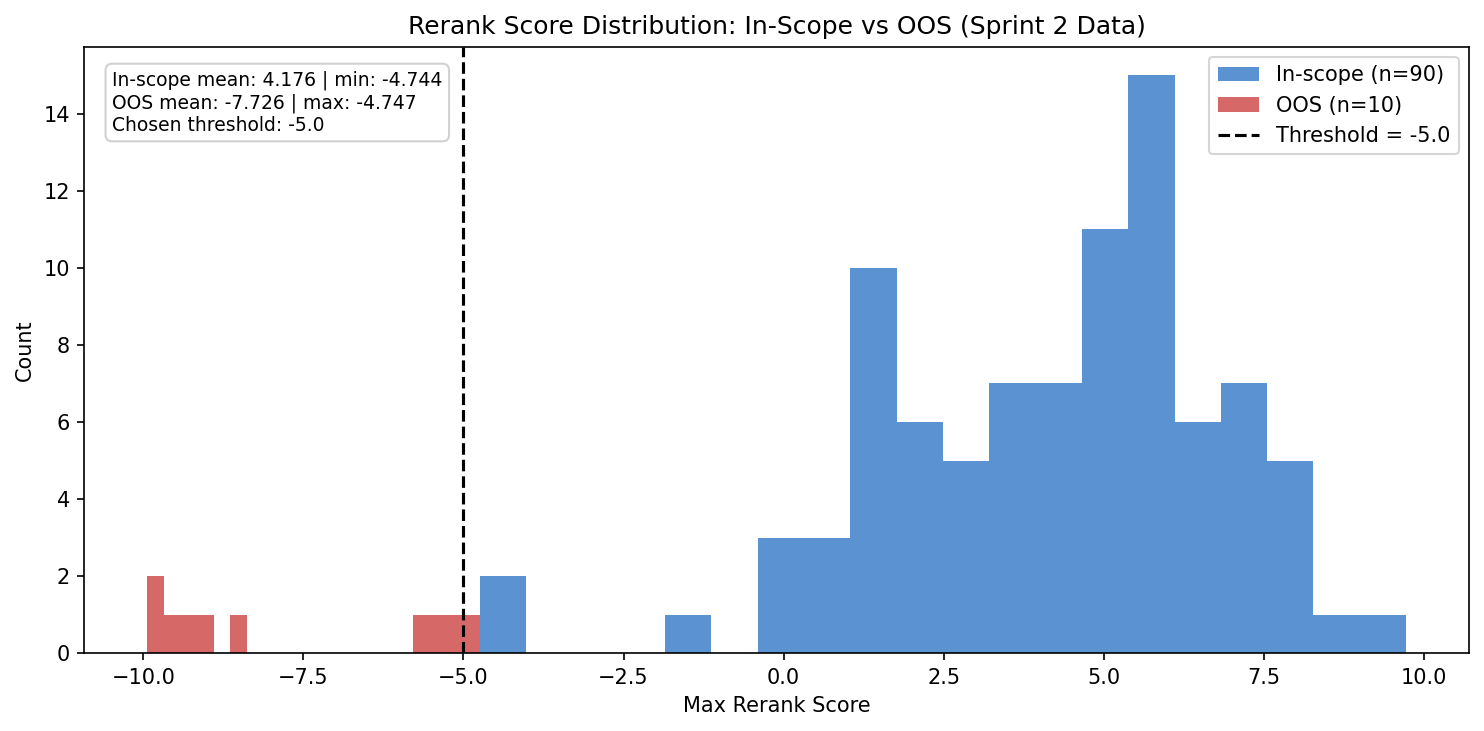

Saved: /Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/evaluations/sprint-3/sprint3_oos_threshold_calibration.png
In-scope mean: 4.176, min: -4.744
OOS mean: -7.726, max: -4.747
Current threshold: -5.0


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import json
from IPython.display import Image as IPythonImage, display

SPRINT3_OUTPUT_DIR = os.path.join(project_root, "evaluations", "sprint-3")
os.makedirs(SPRINT3_OUTPUT_DIR, exist_ok=True)

def save_sprint3_plot(filename: str):
    output_path = os.path.join(SPRINT3_OUTPUT_DIR, filename)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()
    display(IPythonImage(filename=output_path))
    print(f"Saved: {output_path}")

def add_bar_labels(ax, bars, fmt="{:.3f}", fontsize=8, dy=0.01, color=None, rotation=0):
    for bar in bars:
        height = bar.get_height()
        if pd.isna(height):
            continue
        label_color = color or bar.get_facecolor()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + dy,
            fmt.format(height),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            fontweight="bold",
            color=label_color,
            rotation=rotation,
        )

# Load sprint 2 results and eval dataset for categories
s2_results = pd.read_csv(os.path.join(project_root, "evaluations", "sprint-2", "sprint2_eval_results.csv"))
with open(os.path.join(project_root, "evaluations", "eval_questions.json")) as f:
    eval_data = json.load(f)
categories = [item.get("category", "unknown") for item in eval_data]
if len(categories) == len(s2_results):
    s2_results["category"] = categories

# Analyse rerank scores by category
if "max_rerank_score" in s2_results.columns:
    inscope = s2_results[s2_results["category"] != "out_of_scope"]["max_rerank_score"]
    oos = s2_results[s2_results["category"] == "out_of_scope"]["max_rerank_score"]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(inscope, bins=20, alpha=0.7, label=f"In-scope (n={len(inscope)})", color="#1565c0")
    ax.hist(oos, bins=20, alpha=0.7, label=f"OOS (n={len(oos)})", color="#c62828")
    ax.axvline(x=OOS_RERANK_THRESHOLD, color="black", linestyle="--", label=f"Threshold = {OOS_RERANK_THRESHOLD}")
    ax.text(
        0.02,
        0.96,
        f"In-scope mean: {inscope.mean():.3f} | min: {inscope.min():.3f}\n"
        f"OOS mean: {oos.mean():.3f} | max: {oos.max():.3f}\n"
        f"Chosen threshold: {OOS_RERANK_THRESHOLD}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#cccccc", "alpha": 0.9},
    )
    ax.set_xlabel("Max Rerank Score")
    ax.set_ylabel("Count")
    ax.set_title("Rerank Score Distribution: In-Scope vs OOS (Sprint 2 Data)")
    ax.legend()
    save_sprint3_plot("sprint3_oos_threshold_calibration.png")
    
    print(f"In-scope mean: {inscope.mean():.3f}, min: {inscope.min():.3f}")
    print(f"OOS mean: {oos.mean():.3f}, max: {oos.max():.3f}")
    print(f"Current threshold: {OOS_RERANK_THRESHOLD}")
else:
    print("max_rerank_score column not found in sprint 2 results")


In [6]:
test_oos = [
    "What is the best pizza recipe?",
    "Who won the NBA finals?",
    "Write me a poem about clouds",
    "How should I configure my home WiFi router?",
    "What does ISM-0974 say about authentication?",
]

print("Pre-filter tests:")
for q in test_oos:
    passed, reason = pre_filter(q)
    status = "PASS" if passed else "BLOCK"
    print(f"  [{status}] ({reason:12s}) {q}")

Pre-filter tests:
  [BLOCK] (off_topic   ) What is the best pizza recipe?
  [BLOCK] (off_topic   ) Who won the NBA finals?
  [BLOCK] (off_topic   ) Write me a poem about clouds
  [PASS] (uncertain   ) How should I configure my home WiFi router?
  [PASS] (topic_match ) What does ISM-0974 say about authentication?


## 6 - End-to-End Pipeline (Sprint 3)

The full Sprint 3 pipeline: pre-filter, embed, expand, multi-query hybrid search, rerank, rerank threshold check, generate.

In [7]:
def retrieve_sprint3(question: str, include_metadata: bool = False):
    """Full Sprint 3 retrieval: pre-filter -> expand -> multi-query search -> rerank -> guardrail."""
    metadata = {
        "guardrail_stage": None,
        "pre_filter_reason": None,
        "query_variants": [],
        "max_rerank_score": 0.0,
    }

    passed, reason = pre_filter(question)
    metadata["pre_filter_reason"] = reason
    if not passed:
        metadata["guardrail_stage"] = "pre_filter"
        return ([], metadata) if include_metadata else []
    
    queries = expand_query(question)
    metadata["query_variants"] = queries
    
    chunks = multi_query_retrieve(
        supabase,
        lambda q: embed_query(embed_model, q),
        queries,
        match_count=INITIAL_RETRIEVE_COUNT,
    )
    
    reranked = rerank(question, chunks, top_k=RERANK_TOP_K)
    passed, max_score = rerank_threshold_check(reranked, OOS_RERANK_THRESHOLD)
    metadata["max_rerank_score"] = float(max_score)
    
    if not passed:
        metadata["guardrail_stage"] = "rerank_threshold"
        return ([], metadata) if include_metadata else []
    
    return (reranked, metadata) if include_metadata else reranked


def retrieve_sprint3_for_eval(question: str):
    return retrieve_sprint3(question, include_metadata=True)


def generate_sprint3(question: str, chunks: list[dict]) -> str:
    if not chunks:
        return OOS_REFUSAL
    return generate_answer(question, chunks)

# Test with a sample query
test_q = "What are the ISM guidelines for managing cryptographic keys?"
chunks = retrieve_sprint3(test_q)
print(f"Query: {test_q}")
print(f"Retrieved {len(chunks)} chunks")
for i, c in enumerate(chunks):
    print(f"  [{i+1}] {c.get('control_id', 'N/A'):10s} score={c.get('rerank_score', 0):.3f} | {c['content'][:80]}...")

if chunks:
    answer = generate_answer(test_q, chunks)
    print(f"\nAnswer:\n{answer}")

Query: What are the ISM guidelines for managing cryptographic keys?
Retrieved 5 chunks
  [1] ISM-0507   score=6.107 | [Guidelines for cryptography (December 2025) > Communications security doctrine]...
  [2] ISM-1802   score=5.983 | [Guidelines for cryptography (December 2025) > Communications security doctrine]...
  [3] ISM-1091   score=5.880 | [Guidelines for cryptography (December 2025) > Communications security doctrine]...
  [4] ISM-1761   score=5.509 | [Guidelines for cryptography (December 2025) > Communications security doctrine]...
  [5] ISM-0501   score=5.126 | [Guidelines for cryptography (December 2025) > Communications security doctrine]...

Answer:
The retrieved ISM guidance is as follows:

- Cryptographic key management processes and procedures should cover cryptographic key generation, registration, distribution, installation, usage, protection, storage, access, recovery, and destruction. (ISM-1802)
- Well-documented cryptographic key management processes and procedures

## 7 - RAGAS Evaluation

Run the same 100-question evaluation dataset through the Sprint 3 pipeline. Direct comparison with Sprint 1 and Sprint 2.

In [8]:
from src.evaluation import load_eval_dataset, run_ragas_evaluation, compute_ragas_scores, log_metrics_to_clearml
from src.config import EVAL_DATASET_PATH

eval_dataset = load_eval_dataset(EVAL_DATASET_PATH)

print(f"Running Sprint 3 evaluation ({len(eval_dataset)} questions)...")
eval_results = run_ragas_evaluation(
    eval_dataset,
    retrieve_fn=retrieve_sprint3_for_eval,
    generate_fn=generate_sprint3,
)

print("Computing RAGAS scores...")
metrics, results_df = compute_ragas_scores(eval_results)

Loaded 100 evaluation questions.
Running Sprint 3 evaluation (100 questions)...
  [1/100] (14.29s) What is the primary purpose of the Information security manu...
  [2/100] (34.02s) What are the six functions used to group the cyber security ...
  [3/100] (28.56s) How does the ISM define a cyber security incident?...
  [4/100] (18.28s) What is the minimum character length for a password used for...
  [5/100] (25.34s) Who is the intended audience for the Information security ma...
  [6/100] (26.24s) What does the abbreviation AACA stand for?...
ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start
  [7/100] (15.93s) How often must cyber security awareness training be undertak...
  [8/100] (32.92s) How long must event logs be retained in a searchable manner?...
  [9/100] (11.21s) What is the definition of a data spill?...
  [10/100] (16.71s) When are break glass accounts permitted to be used?...
  [11/100] (19.35s) What action must be tak

/Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/src/evaluation.py:162: LangChainDeprecationWarning:

The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import ChatOllama``.

/Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/src/evaluation.py:178: LangChainDeprecationWarning:

The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.



Using Ollama as RAGAS judge (model: llama3.1:8b)


<All keys matched successfully>


Computing RAGAS metrics (sequential, max_retries=5, timeout=300s)...


Evaluating:   0%|          | 0/500 [00:00<?, ?it/s]

Exception raised in Job[73]: TimeoutError()
Exception raised in Job[93]: TimeoutError()
Exception raised in Job[151]: OutputParserException(Invalid json output: The response mentions specific details that a cyber security incident register must contain, such as the date the incident occurred, the date it was discovered, a description of the incident, actions taken, and to whom it was reported. These details are specified in a control (ISM-1803). Based on this analysis, we can generate a question that is likely to be relevant to the response. The question is: What details must be included in a cyber security incident register, according to the ISM guidance? The answer is committal because it provides specific details and references a control (ISM-1803) that specifies these details.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE )
Exception raised in Job[246]: OutputParserException(Invalid json output: What details must be centra

  Set 10 faithfulness scores to 1.0 for correct OOS refusals.
  Set 10 answer_relevancy scores to 1.0 for correct OOS refusals.
  Set 10 context_recall scores to 1.0 for correct OOS refusals.

══════ RAGAS Evaluation Results (All 100 Questions) ══════
  faithfulness              0.8351
  answer_relevancy          0.9078
  context_precision         0.8590
  context_recall            0.9249
  answer_similarity         0.9179
  avg_retrieval_time_s      2.0710
  avg_generation_time_s     19.2692
  avg_total_time_s          21.3402
  avg_max_rerank_score      3.9797

══════ In-Scope Only (90 questions) ══════
  faithfulness              0.8168
  answer_relevancy          0.8972
  context_precision         0.9545
  context_recall            0.9162
  answer_similarity         0.9088

══════ Out-of-Scope Only (10 questions) ══════
  faithfulness              1.0000
  answer_relevancy          1.0000
  context_precision         0.0000
  context_recall            1.0000
  answer_similarity     

### 7.1 - Per-Question RAGAS Scores

In [9]:
display_cols = [c for c in results_df.columns if c != "contexts"]
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)
results_df[display_cols].head(20)

,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall,answer_similarity,category,is_oos_refusal,guardrail_stage,pre_filter_reason,query_variants,retrieval_time_s,generation_time_s,total_time_s,max_rerank_score
0,What is the primary purpose of the Information security ...,[[Using the Information security manual (December 2025) ...,The primary purpose of the Information security manual (...,The purpose of the Information security manual (ISM) is ...,1.000000,1.000000,1.000000,1.000000,0.991515,easy,False,NaN,topic_match,[What is the primary purpose of the Information security...,1.9146,12.3709,14.2855,7.3343
1,What are the six functions used to group the cyber secur...,[[Cyber security principles (December 2025) > Use of the...,The six functions used to group the cyber security princ...,The cyber security principles are grouped into six funct...,1.000000,1.000000,1.000000,1.000000,0.902230,easy,False,NaN,topic_match,[What are the six functions used to group the cyber secu...,4.4697,29.5545,34.0242,6.4964
2,How does the ISM define a cyber security incident?,[[Guidelines for cyber security incidents (December 2025...,A cyber security incident is defined as an unwanted or u...,A cyber security incident is an unwanted or unexpected c...,0.333333,0.870070,1.000000,1.000000,0.995261,easy,False,NaN,topic_match,"[How does the ISM define a cyber security incident?, Wha...",2.1537,26.4061,28.5598,6.0270
3,What is the minimum character length for a password used...,[[Guidelines for system hardening (December 2025) > Oper...,"Based on the retrieved ISM guidance, the minimum charact...","According to ISM-0421, passwords used for single-factor ...",0.333333,1.000000,0.450000,0.090909,0.922180,easy,False,NaN,topic_match,[What is the minimum character length for a password use...,1.9723,16.3091,18.2814,7.8038
4,Who is the intended audience for the Information securit...,[[Using the Information security manual (December 2025) ...,The intended audience for the Information security manua...,The ISM is intended for chief information security offic...,0.500000,0.935275,1.000000,1.000000,0.942921,easy,False,NaN,topic_match,[Who is the intended audience for the Information securi...,1.9011,23.4364,25.3375,5.9239
5,What does the abbreviation AACA stand for?,[[Cyber security terminology (December 2025) > Use of th...,AACA stands for ASD-Approved Cryptographic Algorithm.,AACA stands for ASD-Approved Cryptographic Algorithm.,1.000000,0.962398,1.000000,1.000000,1.000000,easy,False,NaN,uncertain,"[What does the abbreviation AACA stand for?, What is the...",1.7483,24.4904,26.2387,4.9681
6,How often must cyber security awareness training be unde...,[[Guidelines for personnel security (December 2025) > Pr...,"According to the retrieved ISM guidance, cyber security ...","Under ISM-0252, cyber security awareness training is und...",1.000000,0.984889,1.000000,1.000000,0.981975,easy,False,NaN,topic_match,[How often must cyber security awareness training be und...,1.6394,14.2938,15.9332,7.0199
7,How long must event logs be retained in a searchable man...,[[Guidelines for system monitoring (December 2025) > Eve...,"According to the retrieved ISM guidance, event logs must...","According to ISM-1988, event logs must be retained in a ...",1.000000,0.939965,1.000000,1.000000,0.987431,easy,False,NaN,uncertain,[How long must event logs be retained in a searchable ma...,1.5373,31.3874,32.9248,7.2966
8,What is the definition of a data spill?,[... t Data that is being communicated across a communic...,A data spill is the accidental or deliberate exposure of...,A data spill is the accidental or deliberate exposure of...,1.000000,0.960159,1.000000,1.000000,1.000000,easy,False,NaN,topic_match,"[What is the definition of a data spill?, Definition of ...",1.9566,9.2518,11.2084,3.7188
9,When are break glass accounts permitted to be used?,[[Guidelines for personnel security (December 2025) > Pr...,Break glass accounts are o

### 7.2 - RAGAS Metrics Bar Chart

,Metric,Sprint 3,Stretch target,Status
0,faithfulness,0.8351,> 0.78,Met
1,answer_relevancy,0.9078,> 0.82,Met
2,context_precision,0.8590,> 0.85,Met
3,context_recall,0.9249,> 0.91,Met
4,answer_similarity,0.9179,> 0.93,Below stretch target


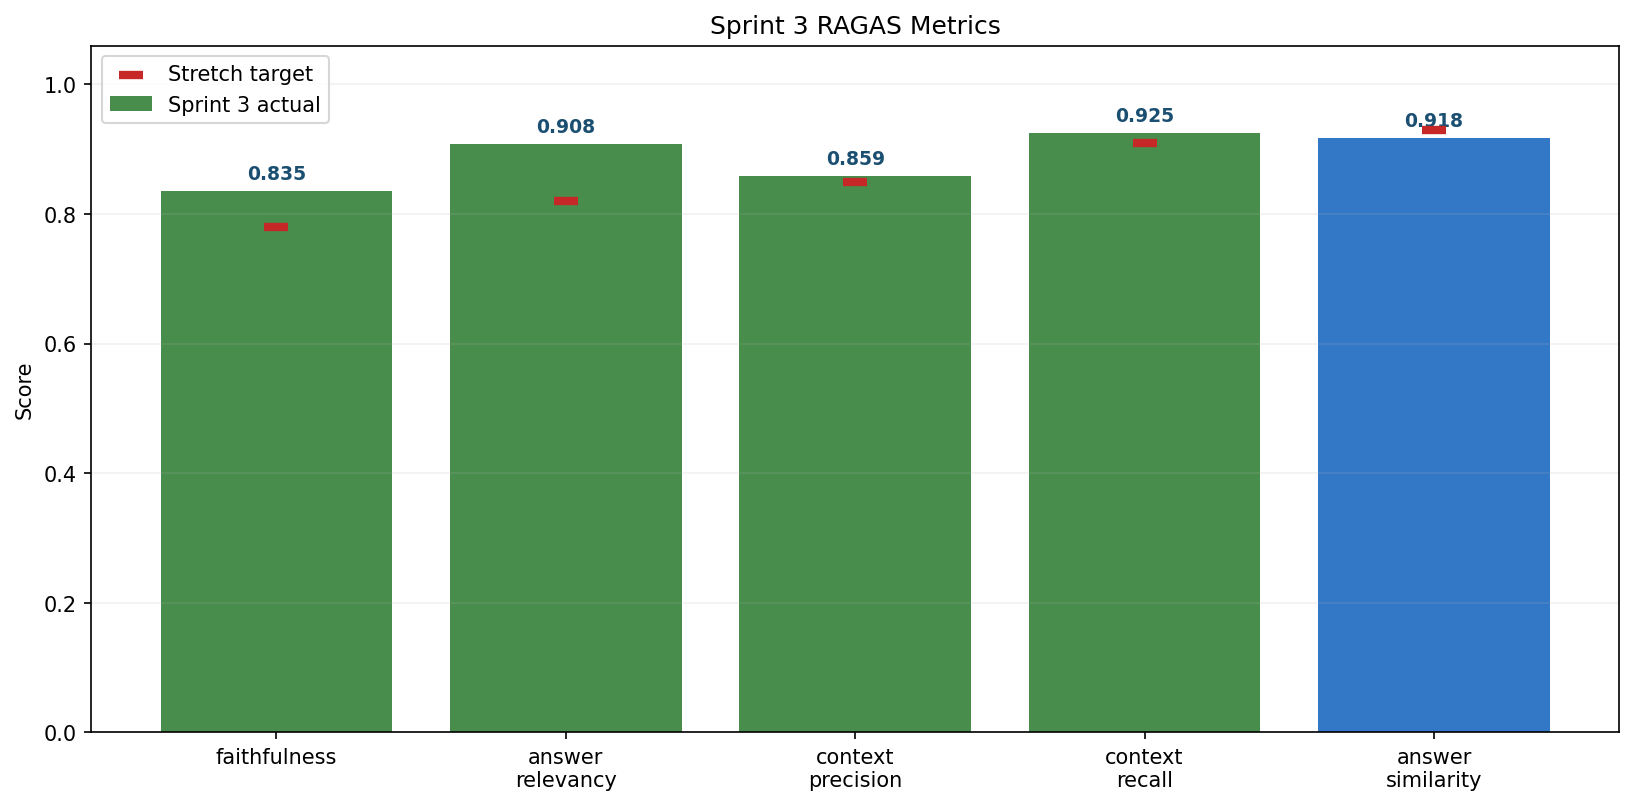

Saved: /Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/evaluations/sprint-3/sprint3_ragas_metrics.png


In [10]:
import numpy as np

metric_names = ["faithfulness", "answer_relevancy", "context_precision", "context_recall", "answer_similarity"]
metric_values = [metrics.get(m, 0) for m in metric_names]
targets = [0.78, 0.82, 0.85, 0.91, 0.93]
metric_labels = [m.replace("_", "\n") for m in metric_names]

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(metric_names))
bar_colors = ["#2e7d32" if v >= t else "#1565c0" for v, t in zip(metric_values, targets)]
bars = ax.bar(x, metric_values, color=bar_colors, alpha=0.88, label="Sprint 3 actual")
ax.scatter(x, targets, color="#c62828", s=130, zorder=5, marker="_", linewidths=4, label="Stretch target")

add_bar_labels(ax, bars, fmt="{:.3f}", fontsize=9, dy=0.012, color="#1b4f72")

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.06)
ax.set_ylabel("Score")
ax.set_title("Sprint 3 RAGAS Metrics")
ax.legend(loc="upper left", frameon=True)
ax.grid(axis="y", alpha=0.18)

status_df = pd.DataFrame({
    "Metric": metric_names,
    "Sprint 3": [f"{v:.4f}" for v in metric_values],
    "Stretch target": [f"> {t:.2f}" for t in targets],
    "Status": ["Met" if v >= t else "Below stretch target" for v, t in zip(metric_values, targets)],
})
display(status_df)
save_sprint3_plot("sprint3_ragas_metrics.png")


### 7.3 - Latency Metrics

Latency Statistics:
       retrieval_time_s  generation_time_s  total_time_s
count          100.0000           100.0000      100.0000
mean             2.0710            19.2692       21.3402
std              1.2949             9.3940       10.0009
min              0.0001             0.0000        0.0001
25%              1.6439            14.0778       16.2418
50%              1.9003            20.1958       22.8262
75%              2.2880            24.7071       26.8946
max              7.6098            51.5681       53.0225


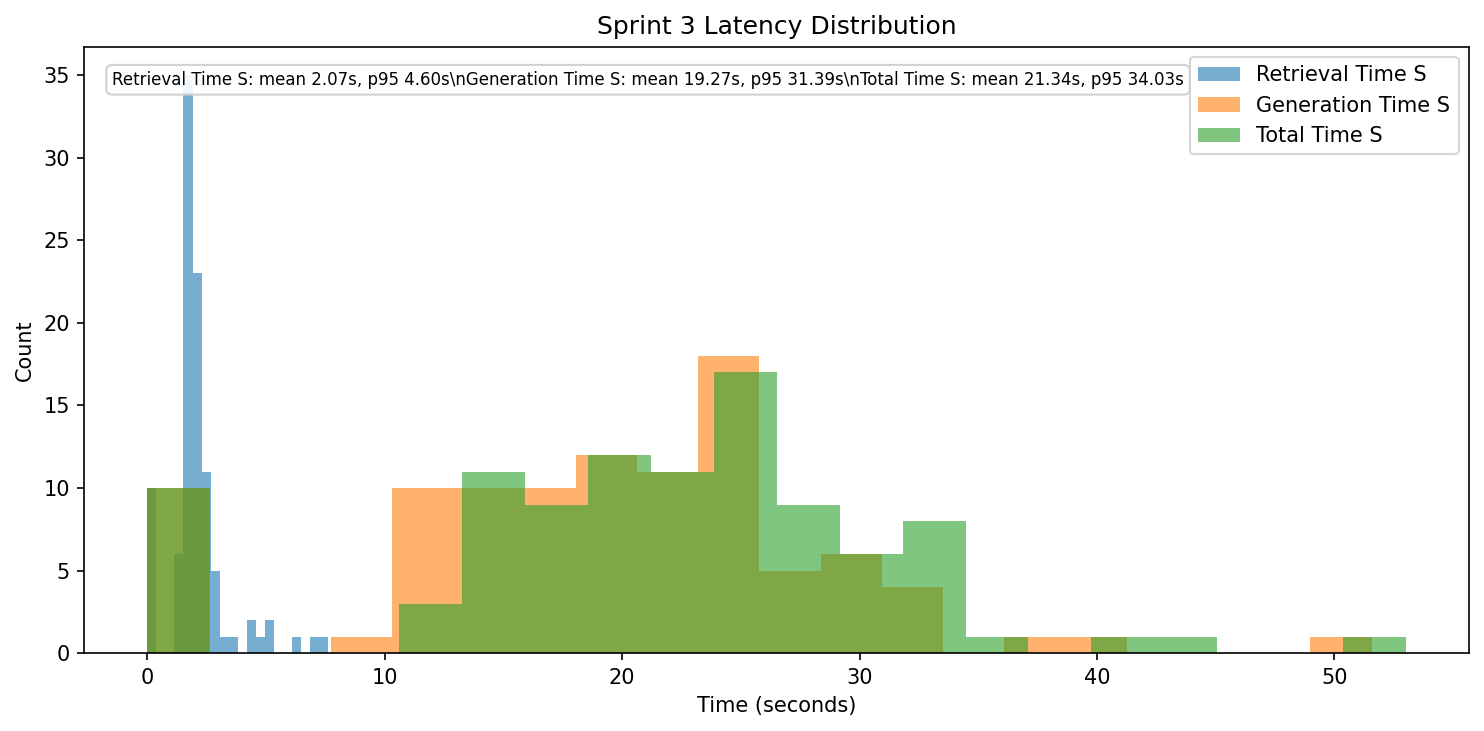

Saved: /Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/evaluations/sprint-3/sprint3_latency.png


In [11]:
latency_cols = ["retrieval_time_s", "generation_time_s", "total_time_s"]
available_cols = [c for c in latency_cols if c in results_df.columns]

if available_cols:
    print("Latency Statistics:")
    latency_stats = results_df[available_cols].describe().round(4)
    print(latency_stats)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    for col in available_cols:
        ax.hist(results_df[col], bins=20, alpha=0.6, label=col.replace("_", " ").title())

    summary_lines = []
    for col in available_cols:
        summary_lines.append(
            f"{col.replace('_', ' ').title()}: mean {results_df[col].mean():.2f}s, p95 {results_df[col].quantile(0.95):.2f}s"
        )
    ax.text(
        0.02,
        0.96,
        "\\n".join(summary_lines),
        transform=ax.transAxes,
        va="top",
        fontsize=8,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#cccccc", "alpha": 0.9},
    )
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Count")
    ax.set_title("Sprint 3 Latency Distribution")
    ax.legend()
    save_sprint3_plot("sprint3_latency.png")


### 7.4 - Scores by Question Category

Per-category average scores:
              faithfulness  answer_relevancy  context_precision  context_recall  answer_similarity
category                                                                                          
easy                0.8367            0.9219             0.9633          0.9318             0.9540
hard                0.7209            0.8262             0.9079          0.8840             0.8933
medium              0.8433            0.9282             0.9669          0.9164             0.8889
out_of_scope        1.0000            1.0000             0.0000          1.0000             1.0000
very_hard           0.8691            0.8815             0.9837          0.9333             0.8642


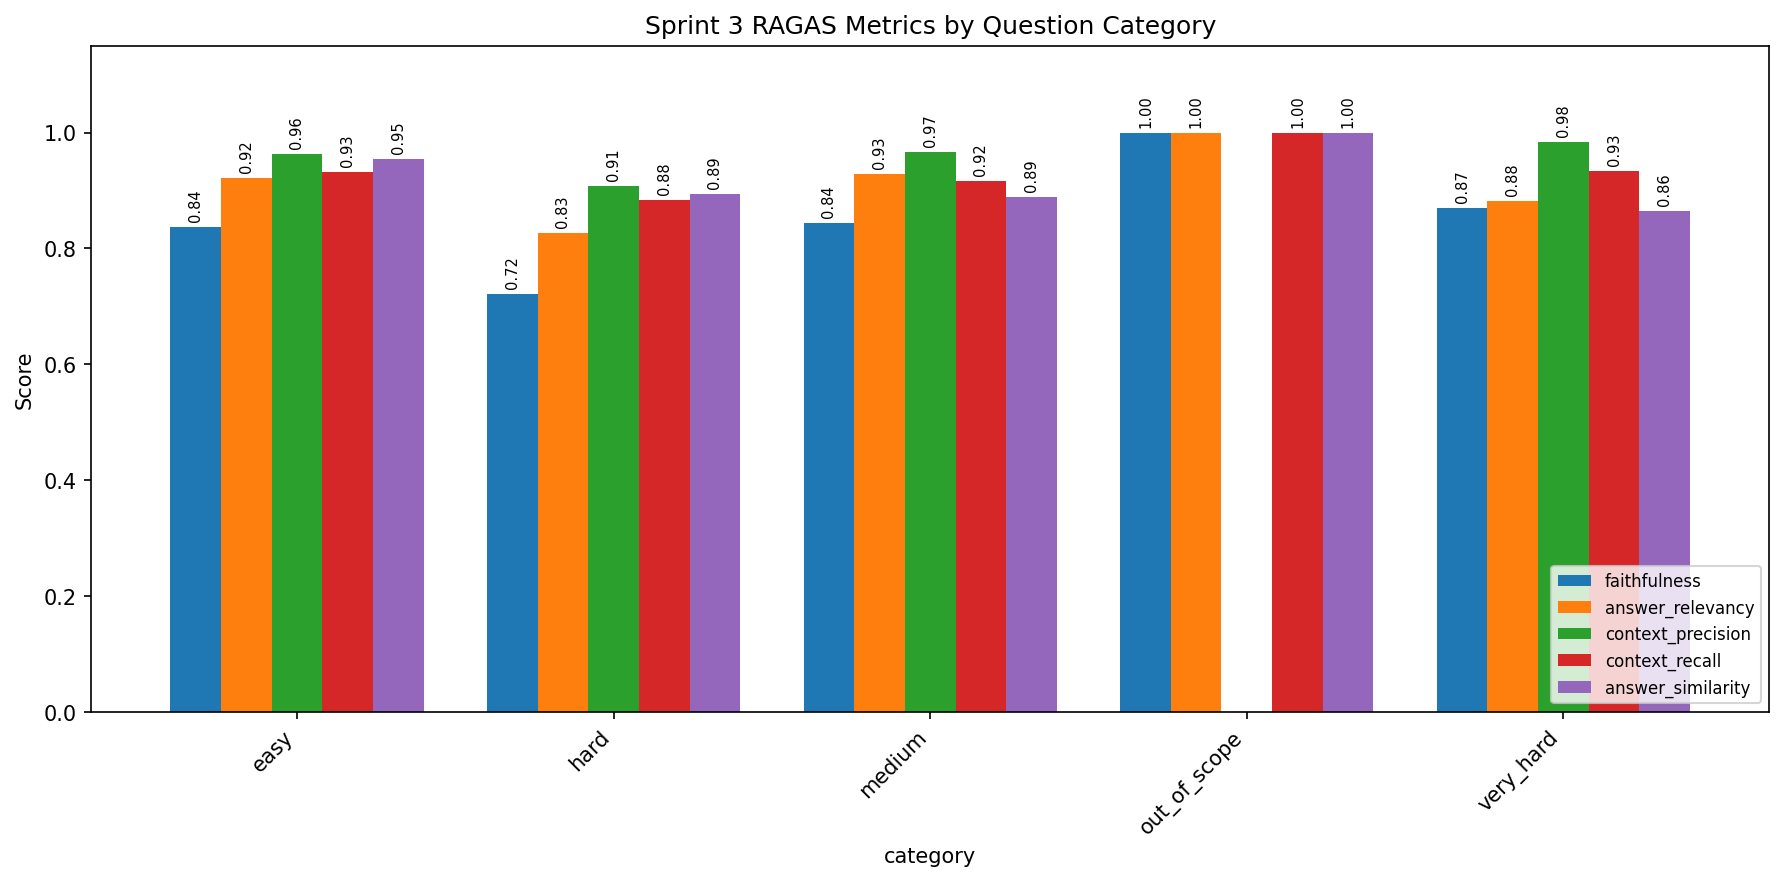

Saved: /Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/evaluations/sprint-3/sprint3_category_breakdown.png


In [12]:
categories = [item.get("category", "unknown") for item in eval_dataset]
if len(categories) == len(results_df):
    results_df["category"] = categories

category_means = results_df.groupby("category")[metric_names].mean()
print("Per-category average scores:")
print(category_means.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
category_means.plot(kind="bar", ax=ax, width=0.8)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.15)
ax.set_title("Sprint 3 RAGAS Metrics by Question Category")
ax.legend(loc="lower right", fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

for bar in ax.patches:
    height = bar.get_height()
    if pd.notna(height) and height > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90,
        )

save_sprint3_plot("sprint3_category_breakdown.png")


### 7.5 - In-Scope vs Out-of-Scope Analysis

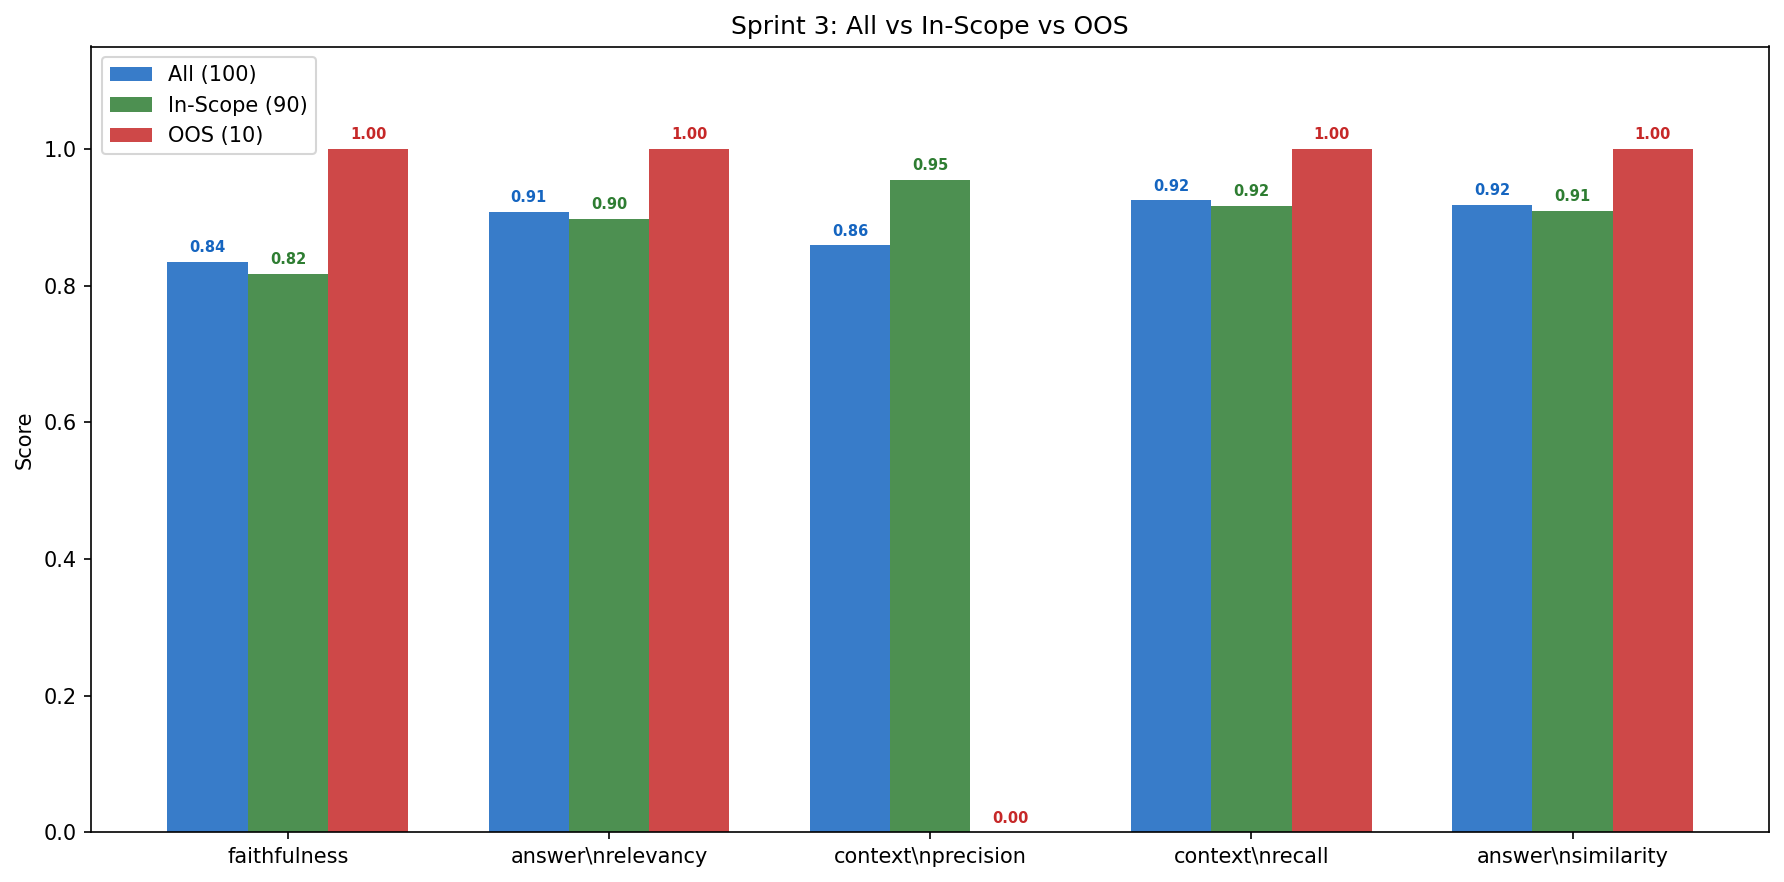

Saved: /Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/evaluations/sprint-3/sprint3_inscope_vs_oos.png


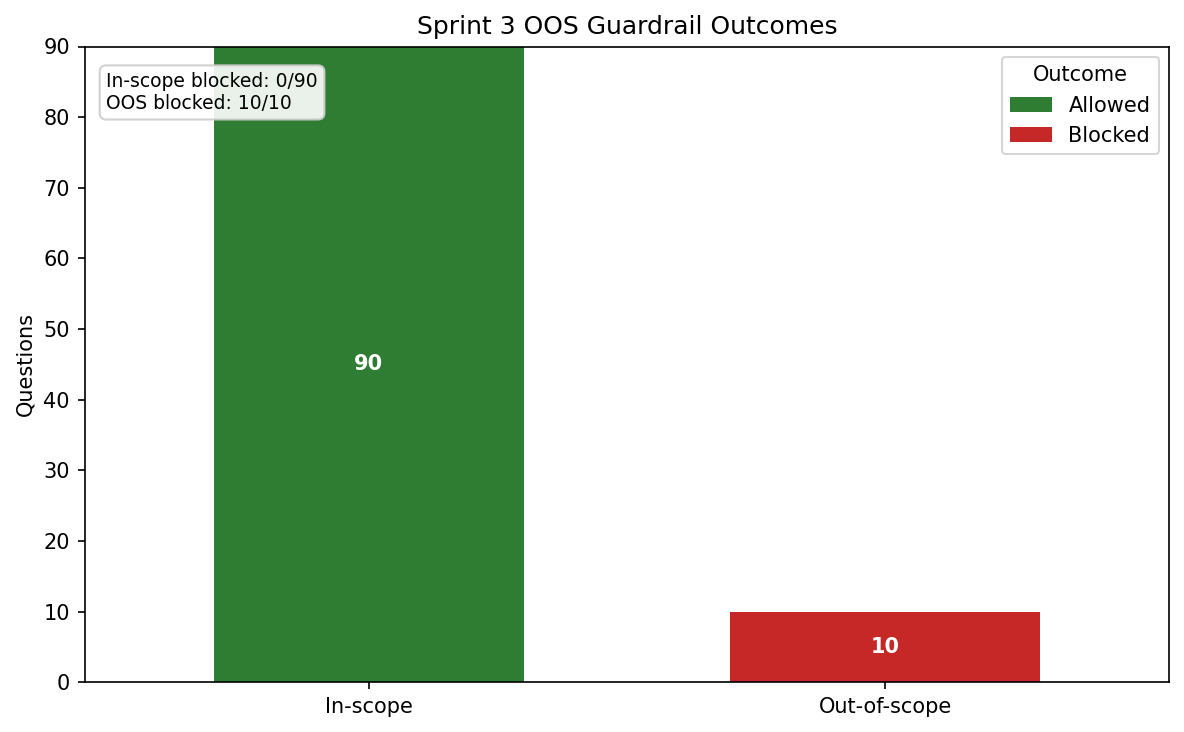

Saved: /Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/evaluations/sprint-3/sprint3_guardrail_outcomes.png


In [13]:
import numpy as np

if "category" in results_df.columns:
    inscope_mask = results_df["category"] != "out_of_scope"
    oos_mask = results_df["category"] == "out_of_scope"
    
    all_means = results_df[metric_names].mean()
    inscope_means = results_df.loc[inscope_mask, metric_names].mean()
    oos_means = results_df.loc[oos_mask, metric_names].mean()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(metric_names))
    width = 0.25
    
    all_bars = ax.bar(x - width, all_means, width, label="All (100)", color="#1565c0", alpha=0.85)
    inscope_bars = ax.bar(x, inscope_means, width, label="In-Scope (90)", color="#2e7d32", alpha=0.85)
    oos_bars = ax.bar(x + width, oos_means, width, label="OOS (10)", color="#c62828", alpha=0.85)
    
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace("_", "\\n") for m in metric_names])
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Score")
    ax.set_title("Sprint 3: All vs In-Scope vs OOS")
    ax.legend()
    add_bar_labels(ax, all_bars, fmt="{:.2f}", fontsize=7, dy=0.01, color="#1565c0")
    add_bar_labels(ax, inscope_bars, fmt="{:.2f}", fontsize=7, dy=0.01, color="#2e7d32")
    add_bar_labels(ax, oos_bars, fmt="{:.2f}", fontsize=7, dy=0.01, color="#c62828")
    save_sprint3_plot("sprint3_inscope_vs_oos.png")

    # Guardrail outcome chart for the Sprint 3 report.
    outcome_df = results_df.copy()
    outcome_df["scope"] = np.where(outcome_df["category"] == "out_of_scope", "Out-of-scope", "In-scope")
    outcome_df["outcome"] = np.where(outcome_df["guardrail_stage"].fillna("") == "", "Allowed", "Blocked")
    outcome_counts = outcome_df.groupby(["scope", "outcome"]).size().unstack(fill_value=0)
    outcome_counts = outcome_counts.reindex(index=["In-scope", "Out-of-scope"], columns=["Allowed", "Blocked"], fill_value=0)

    fig, ax = plt.subplots(figsize=(8, 5))
    outcome_counts.plot(kind="bar", stacked=True, ax=ax, color=["#2e7d32", "#c62828"], width=0.6)
    ax.set_ylabel("Questions")
    ax.set_xlabel("")
    ax.set_title("Sprint 3 OOS Guardrail Outcomes")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Outcome", loc="upper right")

    for container in ax.containers:
        labels = [int(v.get_height()) if v.get_height() > 0 else "" for v in container]
        ax.bar_label(container, labels=labels, label_type="center", color="white", fontweight="bold")

    ax.text(
        0.02,
        0.96,
        f"In-scope blocked: {int(outcome_counts.loc['In-scope', 'Blocked'])}/90\n"
        f"OOS blocked: {int(outcome_counts.loc['Out-of-scope', 'Blocked'])}/10",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#cccccc", "alpha": 0.9},
    )
    save_sprint3_plot("sprint3_guardrail_outcomes.png")


## 8 - Three-Sprint Comparison

Compare Sprint 1, Sprint 2, and Sprint 3 RAGAS metrics side by side.

Three-Sprint Comparison:
           Metric Sprint 1 Sprint 2 Sprint 3 Change vs Sprint 2 Stretch target  Target Met
     faithfulness   0.6834   0.7341   0.8351            +0.1010         > 0.78        True
 answer_relevancy   0.7216   0.7678   0.9078            +0.1400         > 0.82        True
context_precision   0.7885   0.8598   0.8590            -0.0008         > 0.85        True
   context_recall   0.8224   0.8659   0.9249            +0.0590         > 0.91        True
answer_similarity      N/A   0.9057   0.9179            +0.0122         > 0.93       False


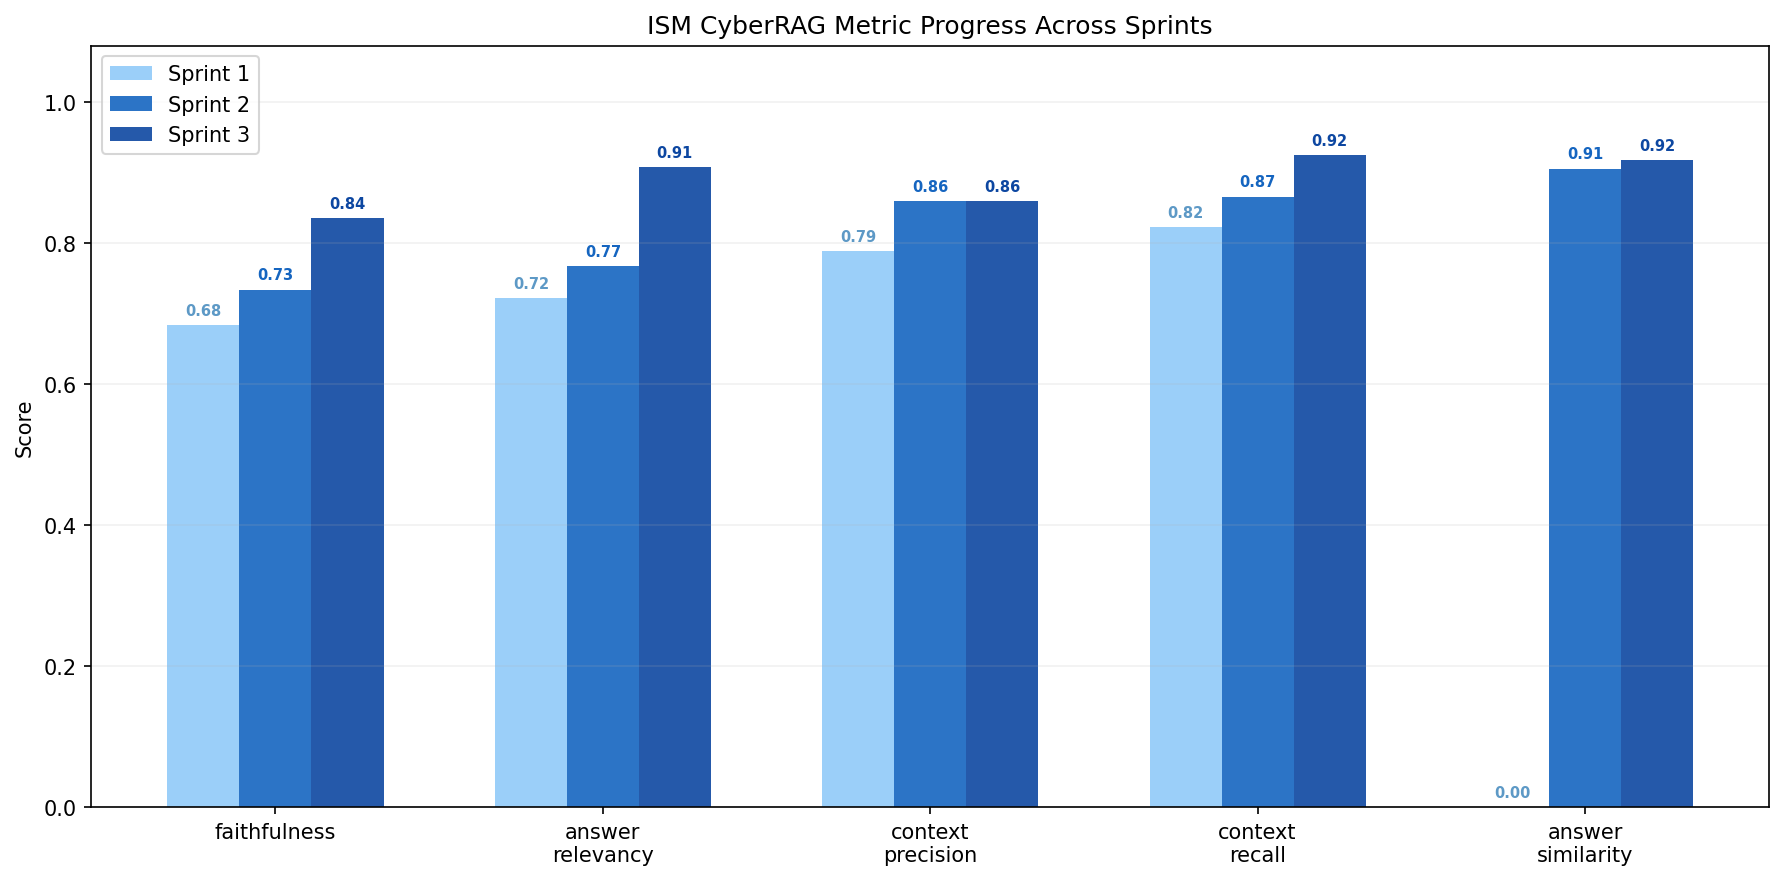

Saved: /Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/evaluations/sprint-3/sprint3_comparison.png


In [14]:
sprint1_scores = {
    "faithfulness": 0.6834,
    "answer_relevancy": 0.7216,
    "context_precision": 0.7885,
    "context_recall": 0.8224,
    "answer_similarity": None,
}

sprint2_scores = {
    "faithfulness": 0.7341,
    "answer_relevancy": 0.7678,
    "context_precision": 0.8598,
    "context_recall": 0.8659,
    "answer_similarity": 0.9057,
}

sprint3_scores = {m: metrics.get(m, 0) for m in metric_names}
targets = {"faithfulness": 0.78, "answer_relevancy": 0.82, "context_precision": 0.85, "context_recall": 0.91, "answer_similarity": 0.93}

comparison_data = []
for m in metric_names:
    s1 = sprint1_scores.get(m)
    s2 = sprint2_scores.get(m)
    s3 = sprint3_scores.get(m)
    t = targets.get(m)
    delta_s2 = None if s2 is None or s3 is None else s3 - s2
    comparison_data.append({
        "Metric": m,
        "Sprint 1": f"{s1:.4f}" if s1 is not None else "N/A",
        "Sprint 2": f"{s2:.4f}" if s2 is not None else "N/A",
        "Sprint 3": f"{s3:.4f}" if s3 is not None else "N/A",
        "Change vs Sprint 2": f"{delta_s2:+.4f}" if delta_s2 is not None else "N/A",
        "Stretch target": f"> {t:.2f}",
        "Target Met": s3 >= t if s3 is not None and t is not None else False,
    })

comparison_df = pd.DataFrame(comparison_data)
print("Three-Sprint Comparison:")
print(comparison_df.to_string(index=False))

# Save comparison CSV
comparison_df.to_csv(os.path.join(SPRINT3_OUTPUT_DIR, "sprint3_vs_sprint2_vs_sprint1.csv"), index=False)

# Main report chart: progress across sprints. Targets are kept in the table above to avoid clutter.
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metric_names))
width = 0.22

s1_vals = [sprint1_scores.get(m, 0) or 0 for m in metric_names]
s2_vals = [sprint2_scores.get(m, 0) or 0 for m in metric_names]
s3_vals = [sprint3_scores.get(m, 0) for m in metric_names]

s1_bars = ax.bar(x - width, s1_vals, width, label="Sprint 1", color="#90caf9", alpha=0.9)
s2_bars = ax.bar(x, s2_vals, width, label="Sprint 2", color="#1565c0", alpha=0.9)
s3_bars = ax.bar(x + width, s3_vals, width, label="Sprint 3", color="#0d47a1", alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", "\n") for m in metric_names])
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("ISM CyberRAG Metric Progress Across Sprints")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.18)
add_bar_labels(ax, s1_bars, fmt="{:.2f}", fontsize=7, dy=0.01, color="#5d99c6")
add_bar_labels(ax, s2_bars, fmt="{:.2f}", fontsize=7, dy=0.01, color="#1565c0")
add_bar_labels(ax, s3_bars, fmt="{:.2f}", fontsize=7, dy=0.01, color="#0d47a1")
save_sprint3_plot("sprint3_comparison.png")


## 9 - ClearML Logging and Save Results

In [15]:
from src.config import EVAL_LLM_PROVIDER, EVAL_LLM_MODEL
from src.evaluation import log_metrics_to_clearml
from src.config import (
    EMBEDDING_MODEL_NAME, RERANKER_MODEL, LLM_MODEL_NAME,
    INITIAL_RETRIEVE_COUNT, RERANK_TOP_K, RRF_K,
    MULTI_QUERY_COUNT, MULTI_QUERY_ENABLED, OOS_RERANK_THRESHOLD,
    QUERY_EXPANSION_MODEL, QUERY_EXPANSION_PROVIDER, QUERY_EXPANSION_RETRIES,
)

params = {
    "sprint": 3,
    "embedding_model": EMBEDDING_MODEL_NAME,
    "reranker_model": RERANKER_MODEL,
    "llm_model": LLM_MODEL_NAME,
    "eval_llm_provider": EVAL_LLM_PROVIDER,
    "eval_llm_model": EVAL_LLM_MODEL,
    "initial_retrieve_count": INITIAL_RETRIEVE_COUNT,
    "rerank_top_k": RERANK_TOP_K,
    "rrf_k": RRF_K,
    "multi_query_count": MULTI_QUERY_COUNT,
    "multi_query_enabled": MULTI_QUERY_ENABLED,
    "query_expansion_provider": QUERY_EXPANSION_PROVIDER,
    "query_expansion_model": QUERY_EXPANSION_MODEL,
    "query_expansion_retries": QUERY_EXPANSION_RETRIES,
    "oos_rerank_threshold": OOS_RERANK_THRESHOLD,
    "chunk_count": chunk_count,
    "eval_questions": len(eval_dataset),
}

log_metrics_to_clearml(metrics, params=params, results_df=results_df, eval_results=eval_results)


Uploaded eval_results artifact (100 rows).
Logged 10 sample Q&A outputs to ClearML.
Logged 19 metrics to ClearML.


### 9.1 - Save Evaluation Results

In [16]:
results_path = os.path.join(project_root, "evaluations", "sprint-3", "sprint3_eval_results.csv")
results_df.to_csv(results_path, index=False)
print(f"Saved: {results_path} ({len(results_df)} rows)")

Saved: /Users/sreekarreddy/Desktop/AIStudio/ism-cyberrag/evaluations/sprint-3/sprint3_eval_results.csv (100 rows)


---
## 10 - Close ClearML Task

In [17]:
from clearml import Task
current = Task.current_task()
if current:
    current.close()
    print(f"ClearML task {current.id} closed.")

ClearML task e006e04a65374026a3f9c3ab882c59e5 closed.
